In [1]:
import json
import os
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np


plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

COLORS = {
    'conceptual' : '#2166AC',
    'factual'    : '#4DAC26',
    'workflow'   : '#D6604D',
    'primary'    : '#2166AC',
    'secondary'  : '#92C5DE',
    'stage1'     : '#2166AC',
    'stage2'     : '#F4A582',
}

In [2]:

COMBINED_FILE = "C:/Users/PC/Downloads/genomeer/datasets/paper_combined_final.jsonl"

rows = []
with open(COMBINED_FILE, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

# Normalize type — rows without 'type' field → 'conceptual'
for r in rows:
    if not r.get('type'):
        r['type'] = 'conceptual'

print(f"Total records loaded : {len(rows):,}")

Total records loaded : 31,636


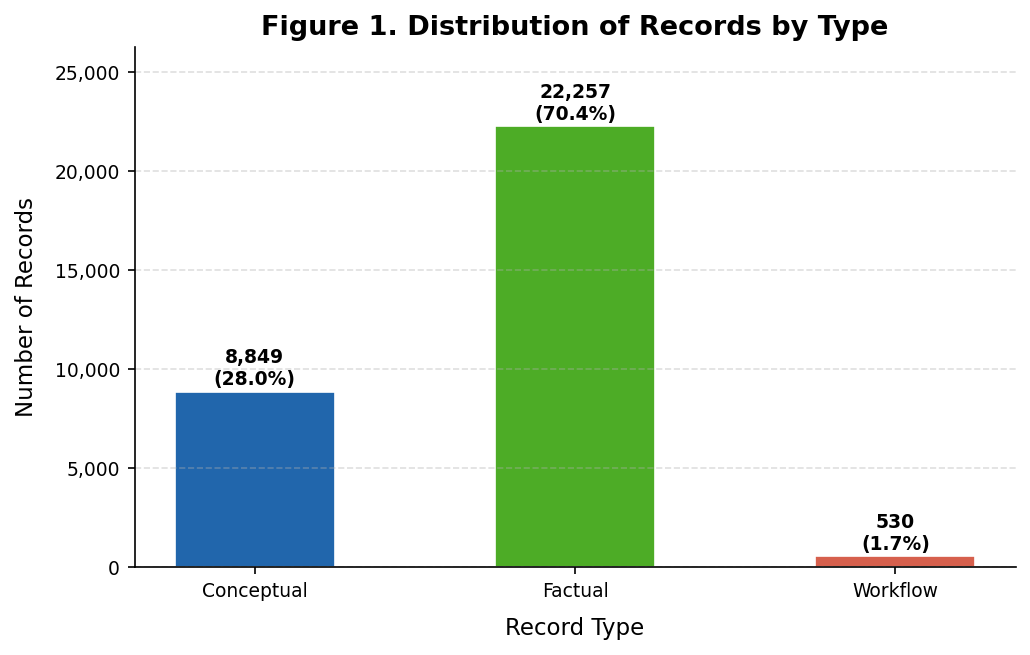

{'Conceptual': 8849, 'Factual': 22257, 'Workflow': 530}


In [3]:
# ── Figure 1 — Distribution by record type ───────────────────────────────────
type_counts = Counter(r.get('type', 'conceptual') for r in rows)
type_order  = ['conceptual', 'factual', 'workflow']
type_labels = {'conceptual': 'Conceptual', 'factual': 'Factual', 'workflow': 'Workflow'}
labels      = [type_labels.get(t, t) for t in type_order if t in type_counts]
values      = [type_counts[t] for t in type_order if t in type_counts]
colors      = [COLORS[t] for t in type_order if t in type_counts]
total       = sum(values)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Record Type', labelpad=8)
ax.set_ylabel('Number of Records', labelpad=8)
ax.set_title('Figure 1. Distribution of Records by Type')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig1_type_distribution.pdf')
plt.savefig('fig1_type_distribution.png')
plt.show()
print(dict(zip(labels, values)))

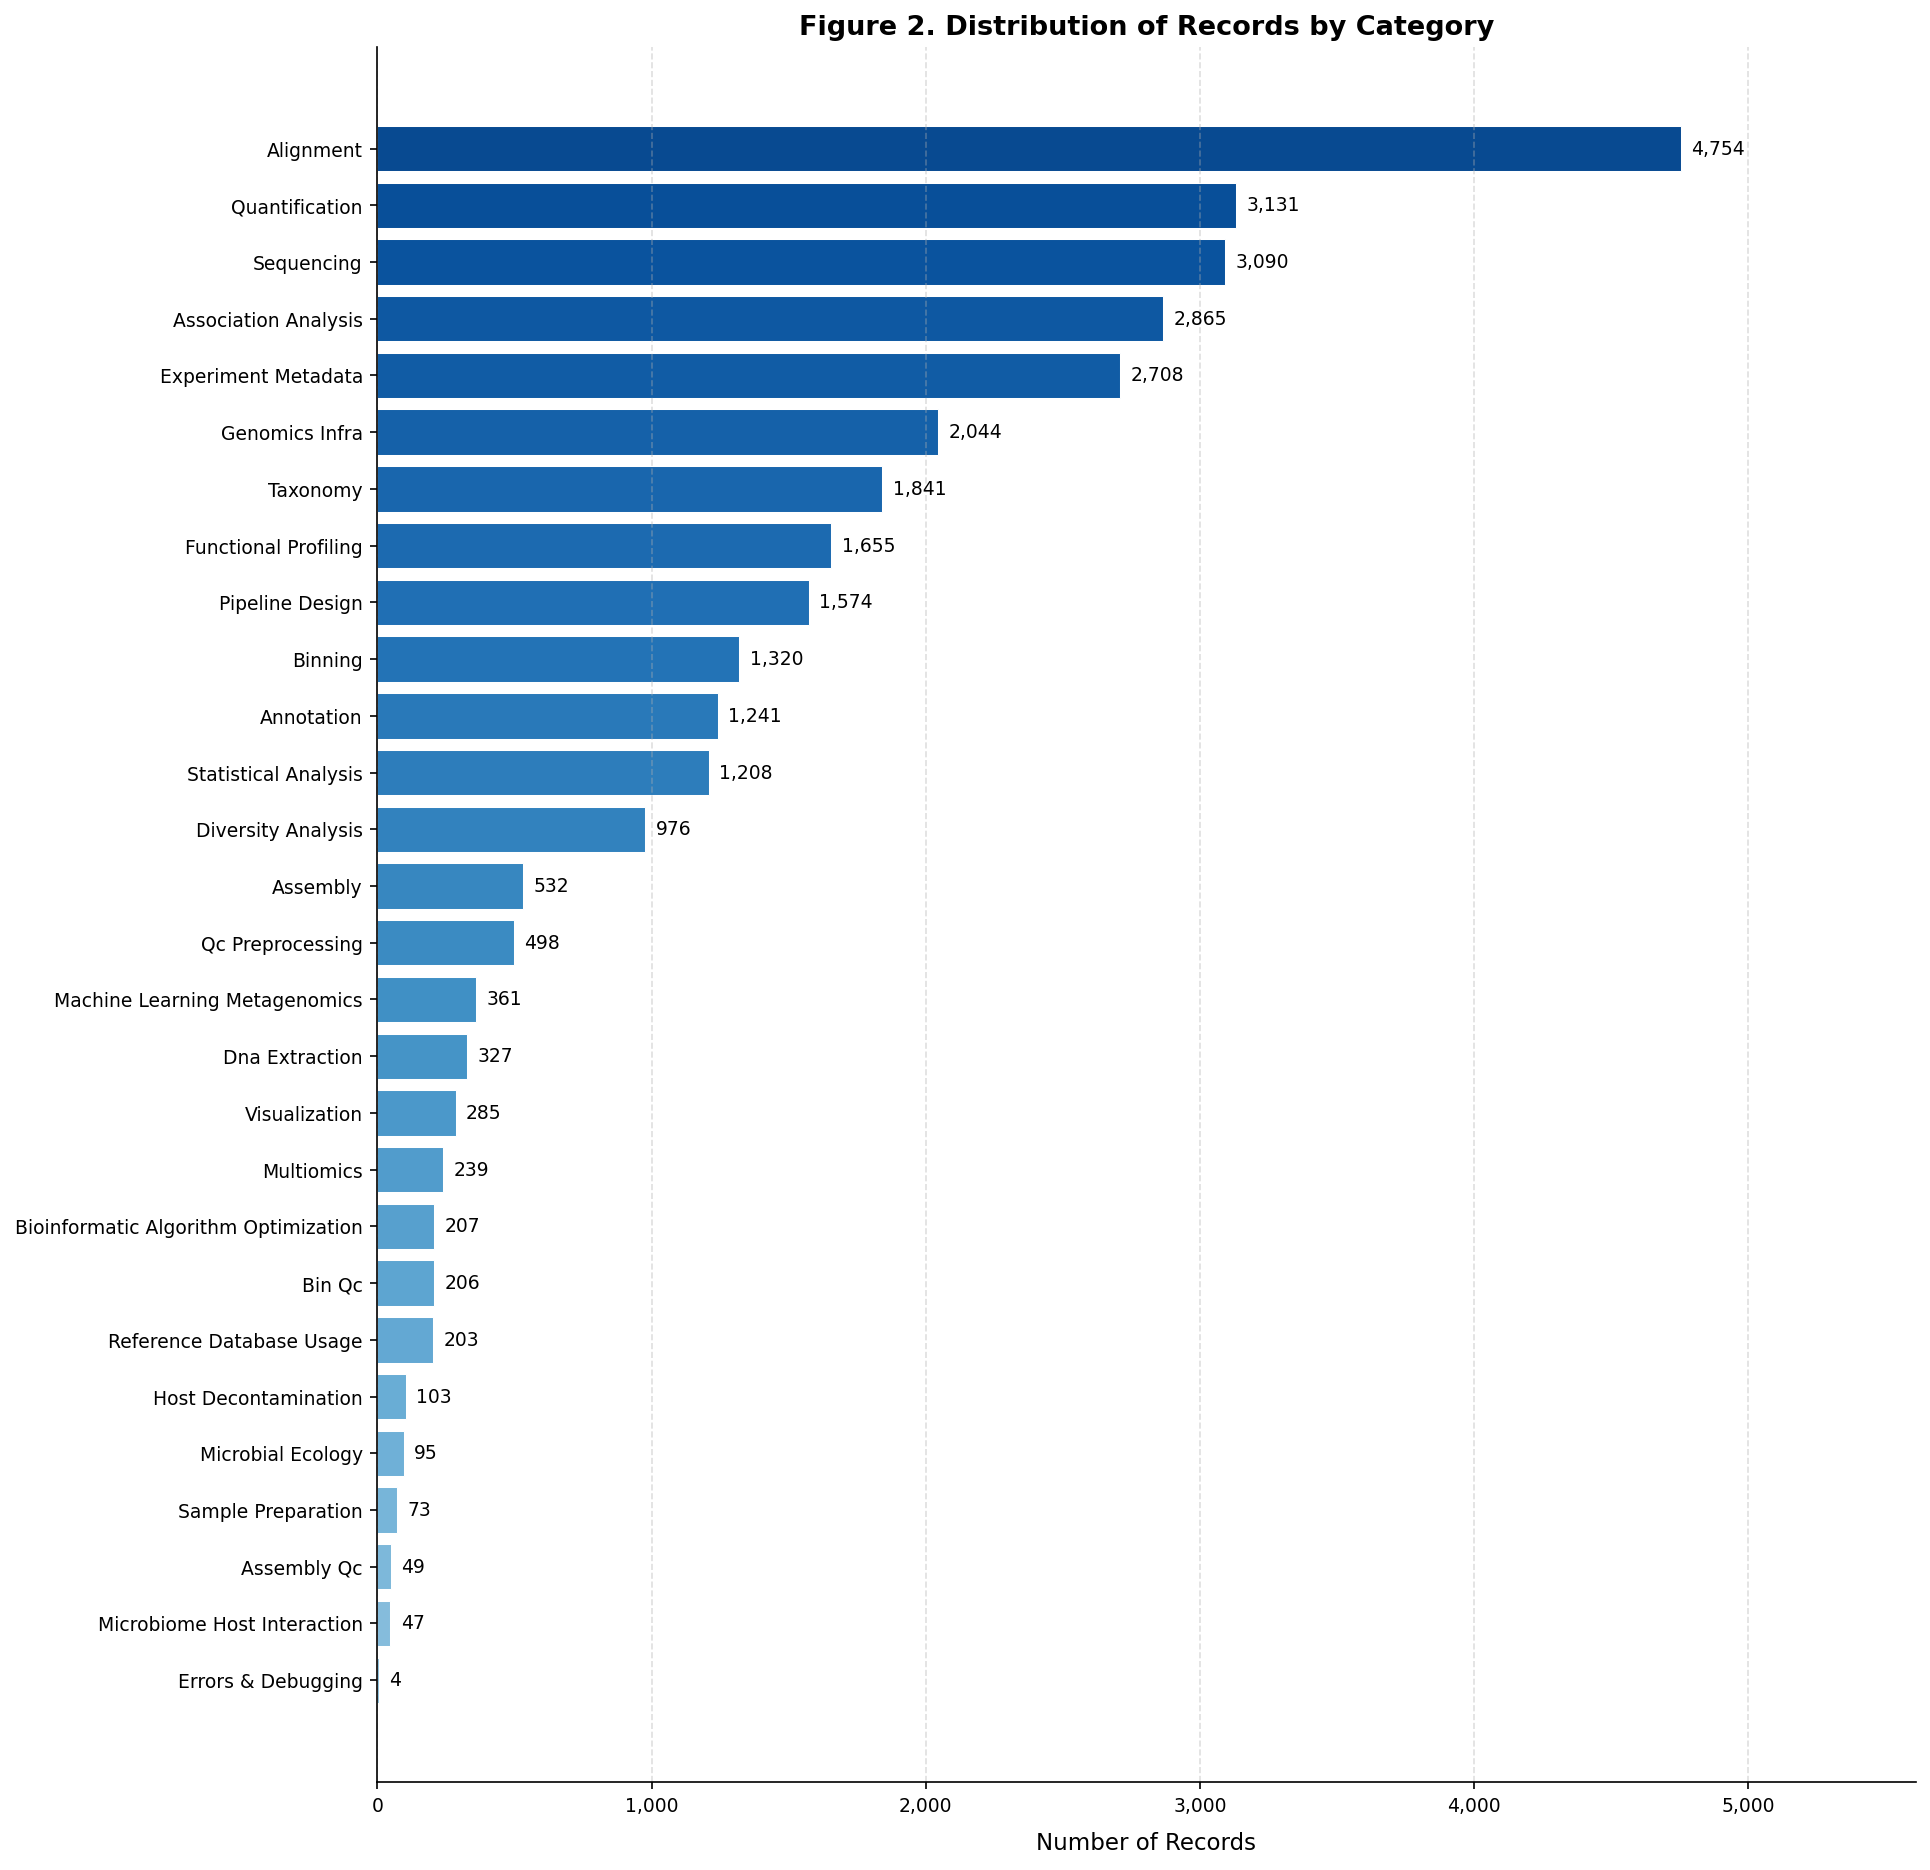

In [4]:
CATEGORY_MERGE_LOCAL = {
    "machine_learning": "machine_learning_metagenomics",
}

cat_counts_raw = Counter(r.get('category', '') for r in rows)

# Merger les catégories
cat_counts = Counter()
for cat, count in cat_counts_raw.items():
    normalized = CATEGORY_MERGE_LOCAL.get(cat.strip().lower(), cat)
    cat_counts[normalized] += count

cat_sorted = cat_counts.most_common()

def fmt_cat(c):
    return c.replace('_', ' ').replace('&', '&').title()

cat_labels = [fmt_cat(c) for c, _ in cat_sorted]
cat_values = [v for _, v in cat_sorted]
n          = len(cat_sorted)

cmap   = plt.cm.Blues
colors = [cmap(0.4 + 0.5 * (n - i) / n) for i in range(n)]

fig, ax = plt.subplots(figsize=(13, max(7, n * 0.45)))
bars = ax.barh(cat_labels[::-1], cat_values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, cat_values[::-1]):
    ax.text(bar.get_width() + max(cat_values) * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Number of Records', labelpad=8)
ax.set_title('Figure 2. Distribution of Records by Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, max(cat_values) * 1.18)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig2_category_distribution.pdf')
plt.savefig('fig2_category_distribution.png')
plt.show()

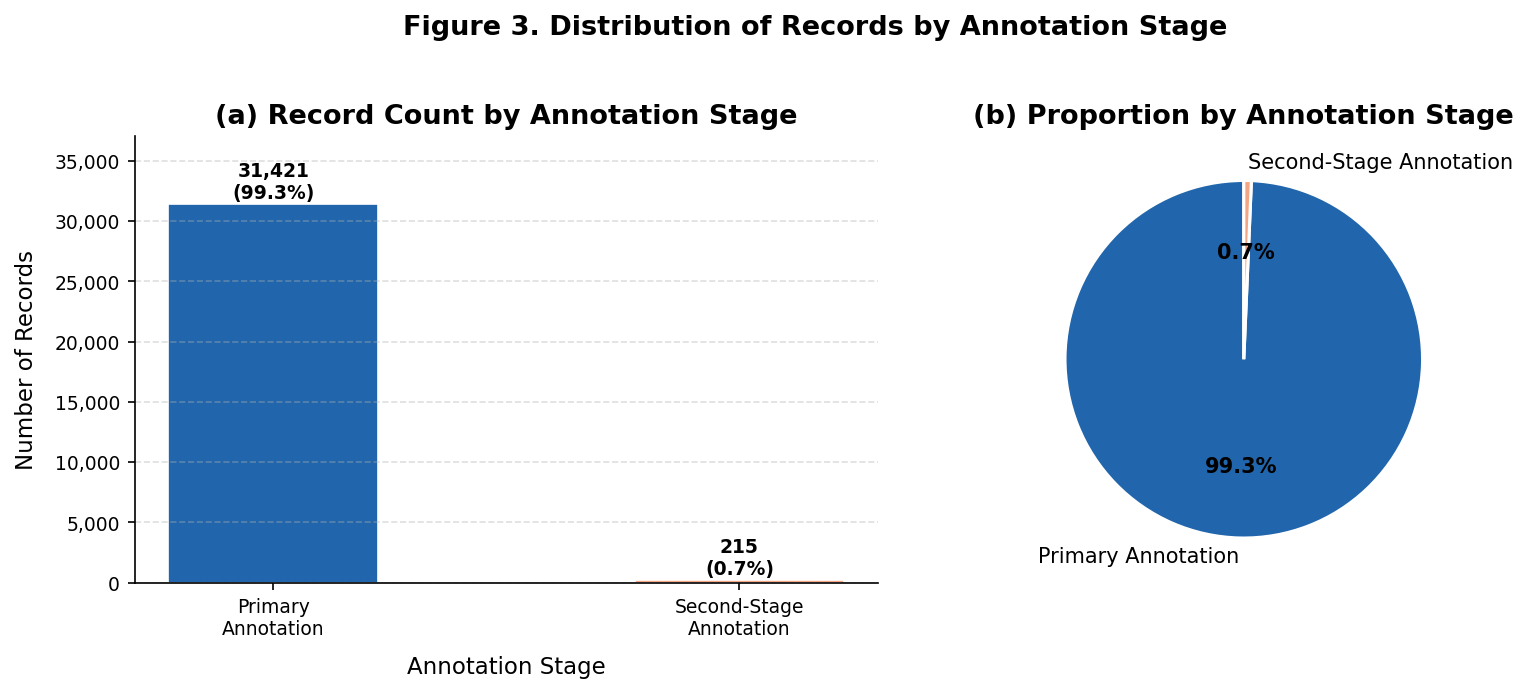

Primary annotation  : 31,421 (99.3%)
Second-stage        : 215 (0.7%)


In [5]:
# ── Figure 3 — Distribution by annotation stage ──────────────────────────────
stage1 = [r for r in rows if r.get('quality') != 'second_stage']
stage2 = [r for r in rows if r.get('quality') == 'second_stage']

n1, n2 = len(stage1), len(stage2)
total  = n1 + n2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left — bar chart
ax = axes[0]
stage_vals   = [n1, n2]
stage_labels = ['Primary\nAnnotation', 'Second-Stage\nAnnotation']
stage_colors = [COLORS['stage1'], COLORS['stage2']]
bars = ax.bar(stage_labels, stage_vals, color=stage_colors,
              width=0.45, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, stage_vals):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Number of Records', labelpad=8)
ax.set_xlabel('Annotation Stage', labelpad=8)
ax.set_title('(a) Record Count by Annotation Stage')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(stage_vals) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Right — pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    stage_vals,
    labels=['Primary Annotation', 'Second-Stage Annotation'],
    colors=stage_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('(b) Proportion by Annotation Stage')

fig.suptitle('Figure 3. Distribution of Records by Annotation Stage',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_stage_distribution.pdf')
plt.savefig('fig3_stage_distribution.png')
plt.show()
print(f"Primary annotation  : {n1:,} ({n1/total*100:.1f}%)")
print(f"Second-stage        : {n2:,} ({n2/total*100:.1f}%)")

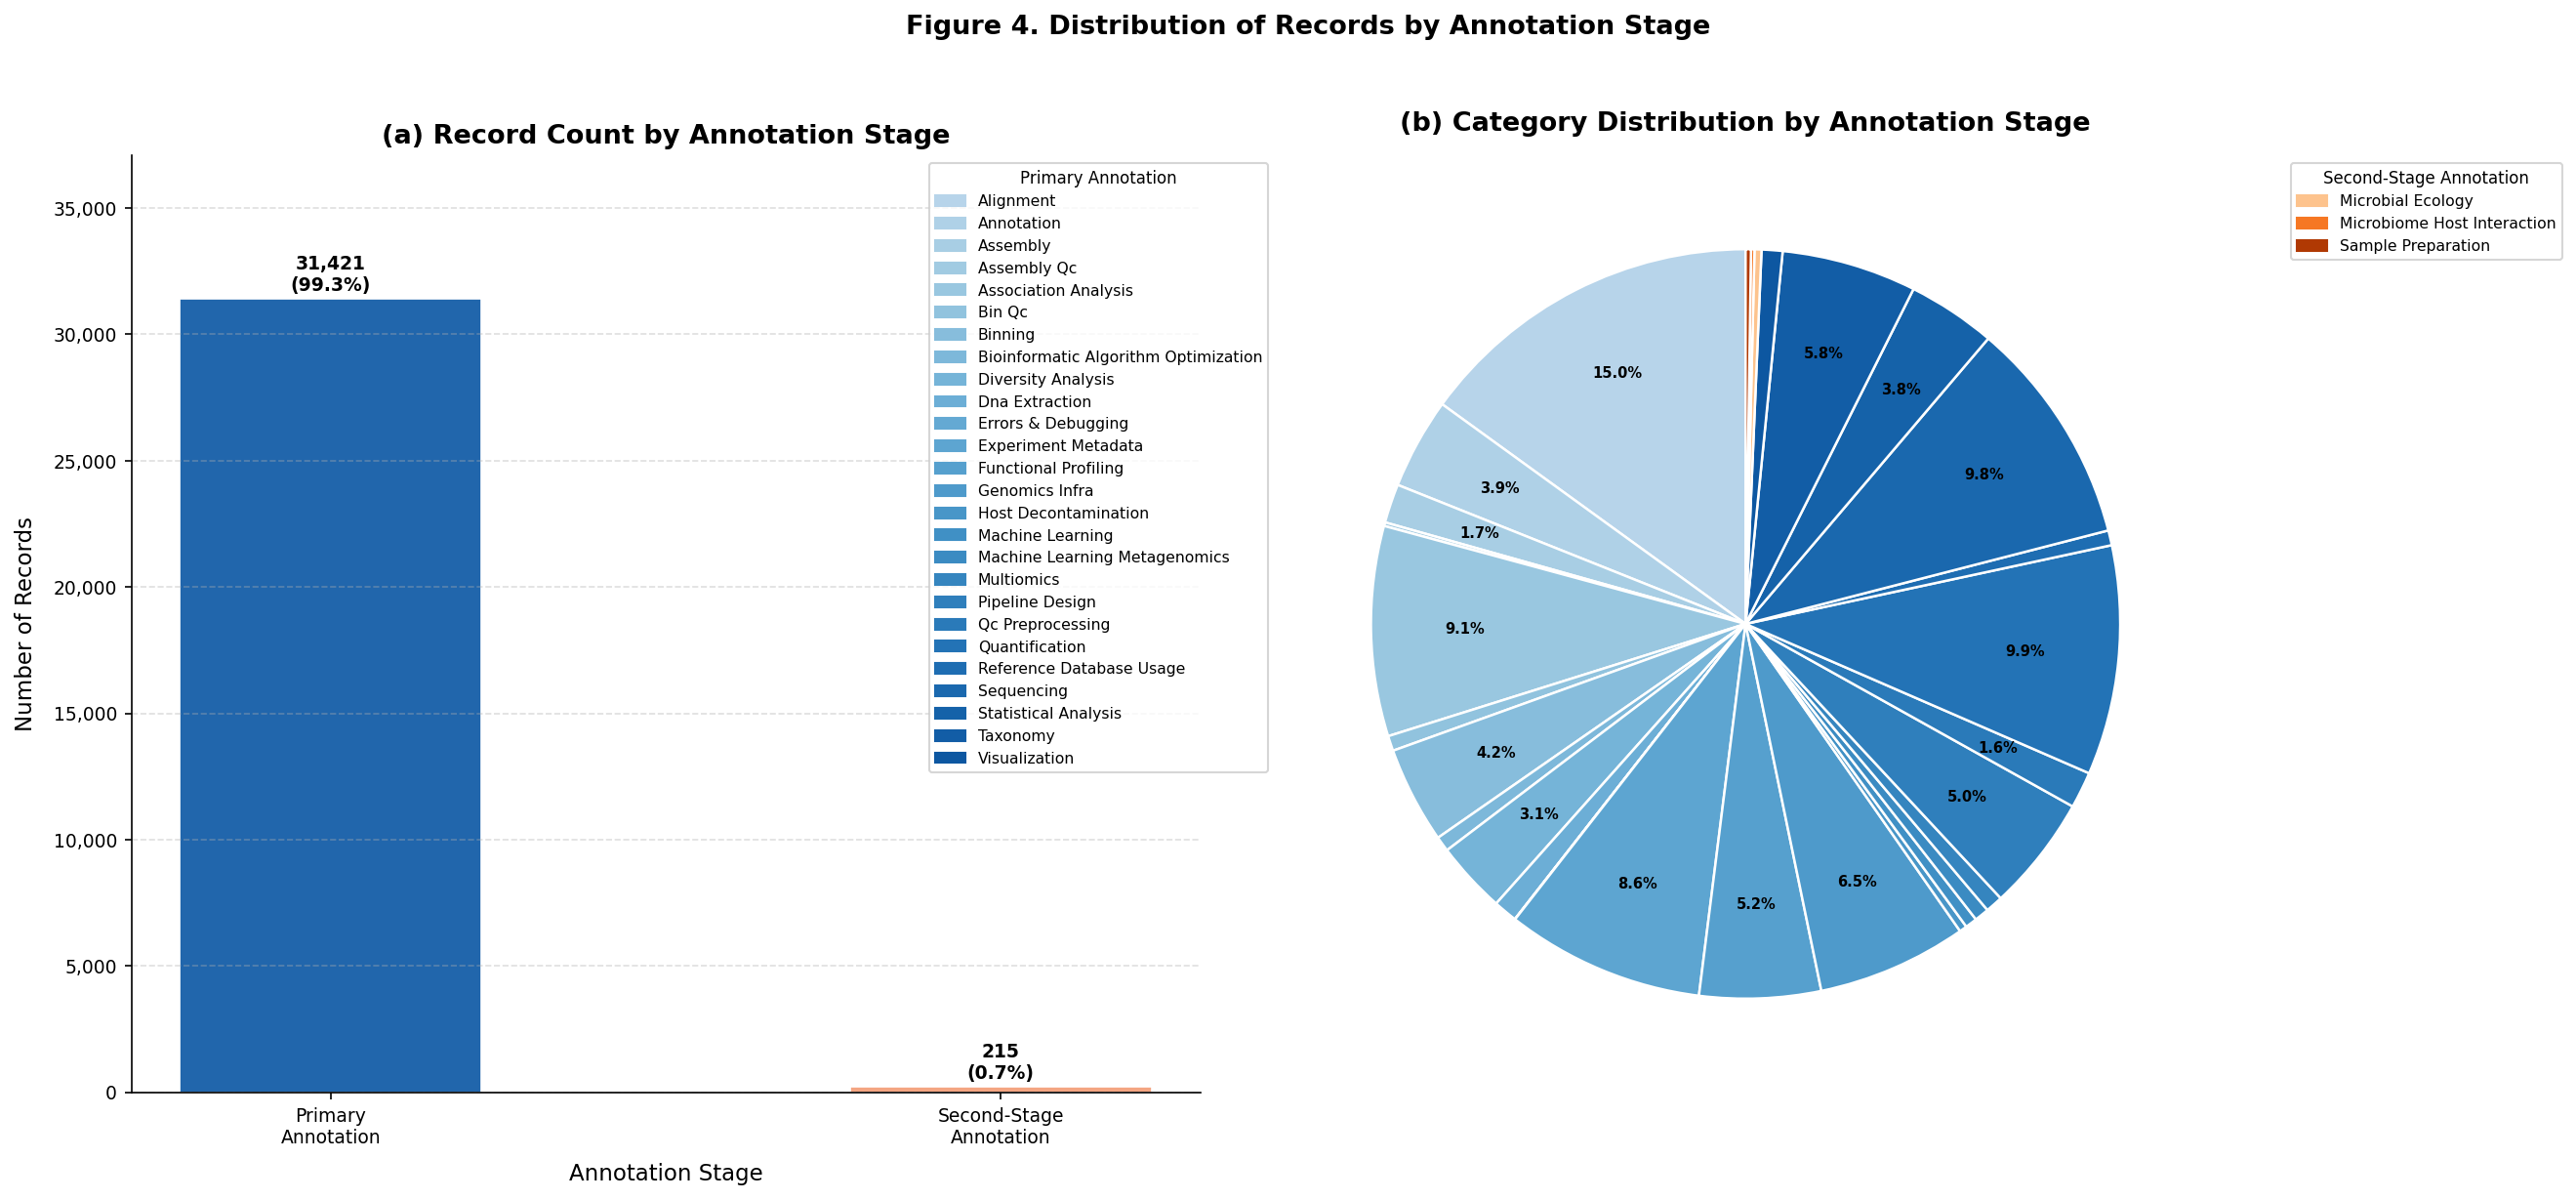

Primary annotation : 31,421 (99.3%)
Second-stage       : 215 (0.7%)


In [6]:
# ── Figure 3 — Distribution by annotation stage ──────────────────────────────
stage1 = [r for r in rows if r.get('quality') != 'second_stage']
stage2 = [r for r in rows if r.get('quality') == 'second_stage']

n1, n2 = len(stage1), len(stage2)
total  = n1 + n2

cats_stage1 = Counter(r.get('category','') for r in stage1)
cats_stage2 = Counter(r.get('category','') for r in stage2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Left — bar chart ──────────────────────────────────────────────────────────
ax = axes[0]
stage_vals   = [n1, n2]
stage_labels = ['Primary\nAnnotation', 'Second-Stage\nAnnotation']
stage_colors = [COLORS['stage1'], COLORS['stage2']]
bars = ax.bar(stage_labels, stage_vals, color=stage_colors,
              width=0.45, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, stage_vals):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Number of Records', labelpad=8)
ax.set_xlabel('Annotation Stage', labelpad=8)
ax.set_title('(a) Record Count by Annotation Stage')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(stage_vals) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Right — pie chart — legend instead of direct labels ──────────────────────
ax2 = axes[1]

cmap_s1 = plt.cm.Blues
cmap_s2 = plt.cm.Oranges

s1_cats = sorted(cats_stage1.keys())
s2_cats = sorted(cats_stage2.keys())

slice_labels = []
slice_values = []
slice_colors = []

for i, cat in enumerate(s1_cats):
    slice_labels.append(('s1', cat.replace('_', ' ').title()))
    slice_values.append(cats_stage1[cat])
    slice_colors.append(cmap_s1(0.3 + 0.55 * i / max(len(s1_cats)-1, 1)))

for i, cat in enumerate(s2_cats):
    slice_labels.append(('s2', cat.replace('_', ' ').title()))
    slice_values.append(cats_stage2[cat])
    slice_colors.append(cmap_s2(0.3 + 0.55 * i / max(len(s2_cats)-1, 1)))

wedges, _, autotexts = ax2.pie(
    slice_values,
    labels=None,
    colors=slice_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(7)
    at.set_fontweight('bold')

legend_patches = [
    mpatches.Patch(color=slice_colors[i], label=label)
    for i, (_, label) in enumerate(slice_labels)
]
n_s1 = len(s1_cats)

leg1 = ax2.legend(
    handles=legend_patches[:n_s1],
    title='Primary Annotation',
    title_fontsize=8,
    loc='upper left',
    bbox_to_anchor=(-0.38, 1.0),
    fontsize=7.5,
    framealpha=0.8,
    ncol=1
)
leg2 = ax2.legend(
    handles=legend_patches[n_s1:],
    title='Second-Stage Annotation',
    title_fontsize=8,
    loc='upper right',
    bbox_to_anchor=(1.38, 1.0),
    fontsize=7.5,
    framealpha=0.8,
    ncol=1
)
ax2.add_artist(leg1)
ax2.set_title('(b) Category Distribution by Annotation Stage', pad=12)

fig.suptitle('Figure 4. Distribution of Records by Annotation Stage',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_stage_distribution.pdf', bbox_inches='tight')
plt.savefig('fig4_stage_distribution.png', bbox_inches='tight')
plt.show()
print(f"Primary annotation : {n1:,} ({n1/total*100:.1f}%)")
print(f"Second-stage       : {n2:,} ({n2/total*100:.1f}%)")

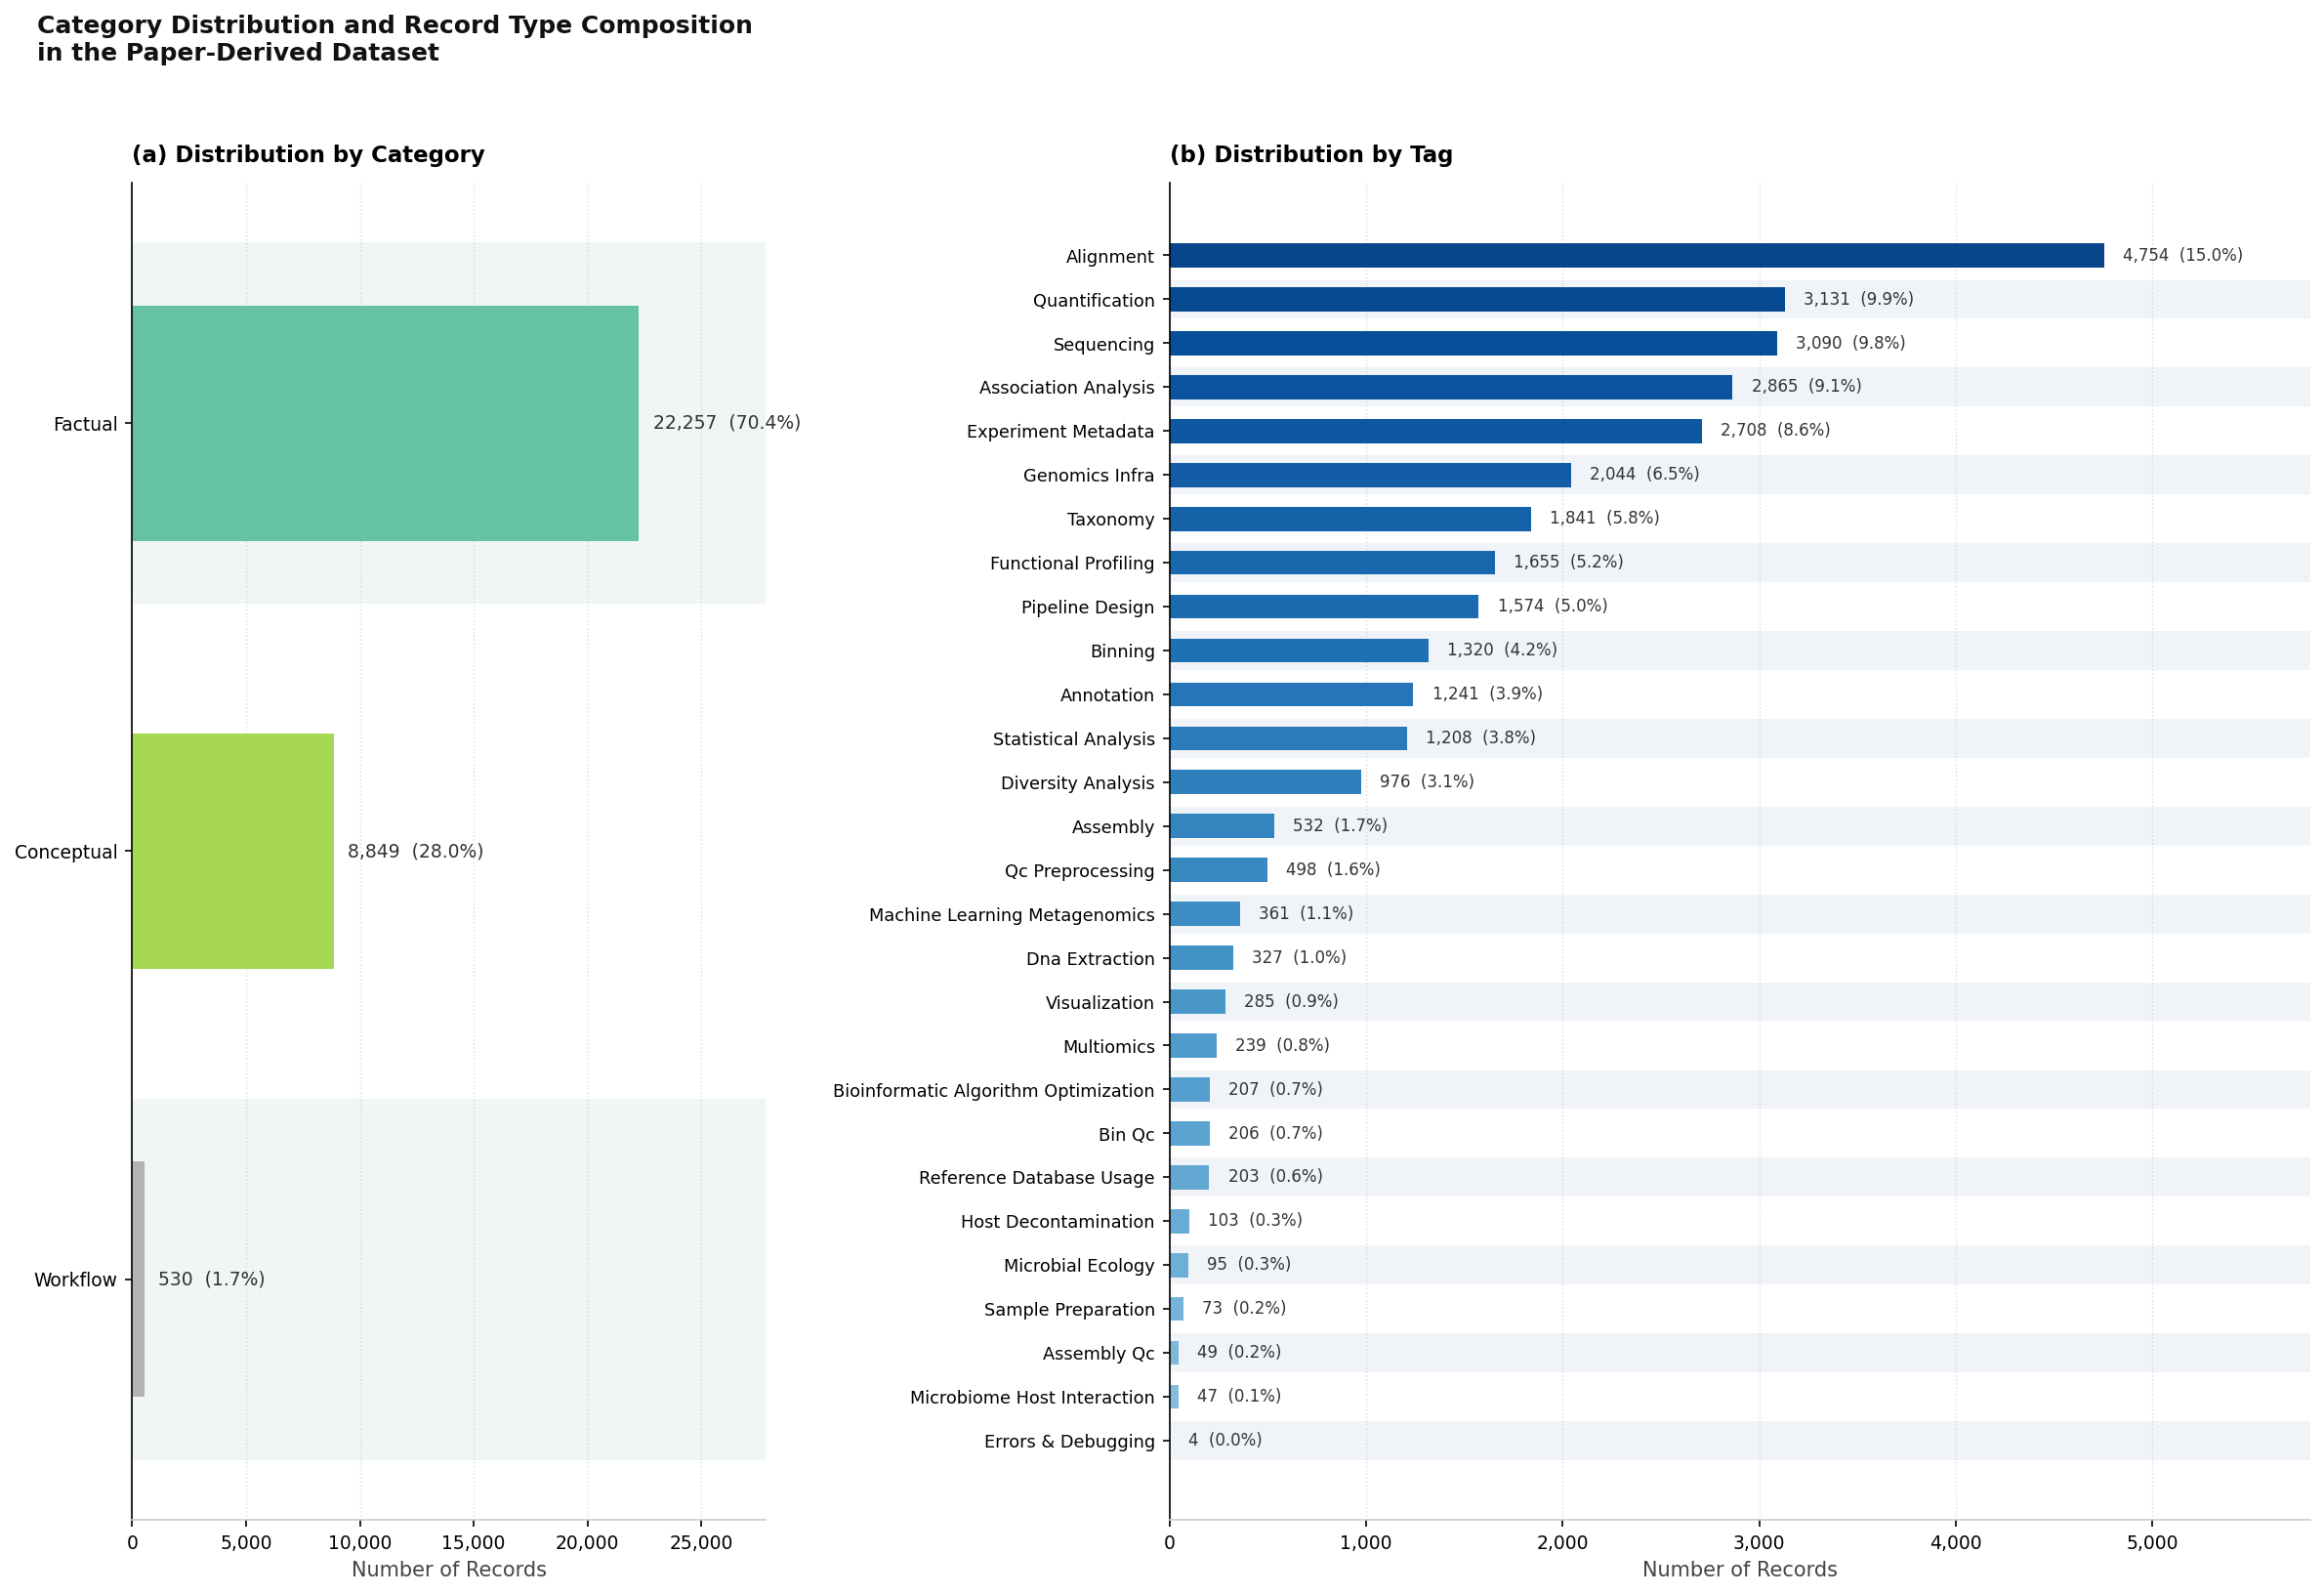

Total records : 31,636
  Factual                   : 22,257 (70.4%)
  Conceptual                : 8,849 (28.0%)
  Workflow                  : 530 (1.7%)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

plt.rcParams.update({
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': 'white',
})

# ── Normalize type ────────────────────────────────────────────────────────────
def get_type(row):
    t = str(row.get("type", "")).strip().lower()
    if t == "workflow":
        return "Workflow"
    elif t == "factual":
        return "Factual"
    elif t == "conceptual":
        return "Conceptual"
    else:
        return "Conceptual"

type_counter_fig = Counter(get_type(r) for r in rows)

# ── Category distribution ─────────────────────────────────────────────────────
CATEGORY_MERGE_LOCAL = {"machine_learning": "machine_learning_metagenomics"}

cat_counts_raw = Counter(r.get('category', '') for r in rows)
cat_counts = Counter()
for cat, count in cat_counts_raw.items():
    normalized = CATEGORY_MERGE_LOCAL.get(cat.strip().lower(), cat)
    cat_counts[normalized] += count

cat_sorted = cat_counts.most_common()
cat_labels = [c.replace('_', ' ').title() for c, _ in cat_sorted]
cat_values = [v for _, v in cat_sorted]

n_cat      = len(cat_sorted)
total_cat  = sum(cat_values)

# ── Type distribution (NEW: bar chart instead of pie) ─────────────────────────
type_sorted = type_counter_fig.most_common()
type_labels = [t for t, _ in type_sorted]
type_values = [v for _, v in type_sorted]

n_type     = len(type_sorted)
total_type = sum(type_values)

# Colors
cmap_cat  = plt.cm.Blues
colors_cat = [cmap_cat(0.4 + 0.5 * (n_cat - i) / max(n_cat-1, 1)) for i in range(n_cat)]

cmap_type = plt.cm.Set2
colors_type = [cmap_type(i / max(n_type-1, 1)) for i in range(n_type)]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(7, n_cat * 0.38)),
                         gridspec_kw={'width_ratios': [1, 1.8]})
fig.patch.set_facecolor('white')

# ── LEFT — Type distribution (segment bar chart) ──────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('white')

for i in range(n_type):
    if i % 2 == 0:
        ax1.axhspan(i - 0.42, i + 0.42, color='#F0F7F2', zorder=0)

bars1 = ax1.barh(type_labels[::-1], type_values[::-1],
                 color=colors_type[::-1],
                 height=0.55, edgecolor='none', zorder=2)

for bar, val in zip(bars1, type_values[::-1]):
    pct = val / total_type * 100
    ax1.text(bar.get_width() + total_type * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}  ({pct:.1f}%)',
             va='center', ha='left', fontsize=9, color='#333333')

ax1.set_title('(a) Distribution by Category',
              fontsize=11, fontweight='bold', pad=10, loc='left')
ax1.set_xlabel('Number of Records', fontsize=10, color='#444444')
ax1.set_xlim(0, max(type_values) * 1.25)
ax1.tick_params(axis='y', labelsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB')
ax1.spines['bottom'].set_color('#CCCCCC')

# ── RIGHT — Category distribution ─────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

for i in range(n_cat):
    if i % 2 == 0:
        ax2.axhspan(i - 0.42, i + 0.42, color='#F0F4F8', zorder=0)

bars2 = ax2.barh(cat_labels[::-1], cat_values[::-1],
                 color=colors_cat[::-1],
                 height=0.55, edgecolor='none', zorder=2)

for bar, val in zip(bars2, cat_values[::-1]):
    pct = val / total_cat * 100
    ax2.text(bar.get_width() + total_cat * 0.003,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}  ({pct:.1f}%)',
             va='center', ha='left', fontsize=8, color='#333333')

ax2.set_xlabel('Number of Records', fontsize=10, color='#444444')
ax2.set_title('(b) Distribution by Tag',
              fontsize=11, fontweight='bold', pad=10, loc='left')
ax2.set_xlim(0, max(cat_values) * 1.22)
ax2.tick_params(axis='y', labelsize=8.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.5, color='#BBBBBB')
ax2.spines['bottom'].set_color('#CCCCCC')

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    'Category Distribution and Record Type Composition\nin the Paper-Derived Dataset',
    fontsize=12, fontweight='bold', color='#111111',
    y=1.02, x=0.02, ha='left'
)

plt.tight_layout()
plt.savefig('C:/Users/PC/Downloads/genomeer/images_VF/paper_analysis.png',dpi=600)
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"Total records : {total_type:,}")
for t, v in type_sorted:
    print(f"  {t:<25} : {v:,} ({v/total_type*100:.1f}%)")